 # Esercizio 3) Caso con $f: \mathbb{R} \to \mathbb{R}$ 

 Considerare la funzione

   $$
   f(x) = x^4 + x^3 - 2x^2 - 2x,
   $$
   
che ha minimo nel punto $x^* =  0.92222$.

Poi:
1. definire le funzioni python per `f` e `grad_f`;
2. visualizzare la funzione nell'intervallo [-3, 3];
3. calcolare il valore di $f(x^*)$ e verificare che $x^*$ è un punto stazionario di $f$;
4. eseguire sia il metodo del gradiente con passo fisso che con backtracking. 
    - utilizzare $maxit = 100$, $tol_{grad} = 1e-6$ e  $x_0 = 0$, in entrambi in casi;
    - settare i parametri $\alpha=0.01$ come passo fisso e  $\alpha_0 = 1$ per il bt. 
  
    Confrontare le soluzioni e i rispettivi errori. Guardare le soluzioni ottenute sul plot della funzione obiettivo. 
    
    Per il metodo con backtracking, creare i seguenti plot:
    - grafico con iterazioni in ascissa e valore della funzione in ordinata;
    - grafico con iterazioni in ascissa e lunghezza del passo di discesa in ordinata.
5. provare diverse configurazione di parametri, per esempio: 
    - $x_0 = 1$, $\alpha=1$ come passo fisso e  $\alpha_0 = 1$ per il bt;
    - $x_0 = -3$, $\alpha=0.01$ come passo fisso e  $\alpha_0 = 0.1$ per il bt;
    - $x_0 = +3$, $\alpha=0.1$ come passo fisso e  $\alpha_0 = 0.1$ per il bt.

    Confrontare le soluzioni e i rispettivi errori. Guardare le soluzioni ottenute sul plot della funzione obiettivo.

    Per il metodo con backtracking, creare i seguenti plot:
    - grafico con iterazioni in ascissa e valore della funzione in ordinata;
    - grafico con iterazioni in ascissa e lunghezza del passo di discesa in ordinata.
6. modificare il codice col backtracking aggiungendo i criteri di arresto visti a lezione
    - early stopping sulla funzione obiettivo: $| f(x^{k+1})-f(x^{k}) | < {tol_f}\ $ con ${ tol_f} = 1e-6$
    - variazione trascurabile degli iterati: $ || x^{k+1}-x^{k} | < {tol_x}\ $ con ${tol_x} = 1e-6$

    Guardare a come cambiano le soluzioni al variare di $tol_{grad}, tol_f, tol_x$  ciascuno da  $1e-6$ a $1e-3$.



In [1]:
#### punto 1 ########################

import numpy as np
import matplotlib.pyplot as plt

def f(x):
    y = x**4 +x**3 -2*x**2 -2*x
    return y

def grad_f(x):
   y = 4*x**3 + 3*x**2 -4*x -2
   return y


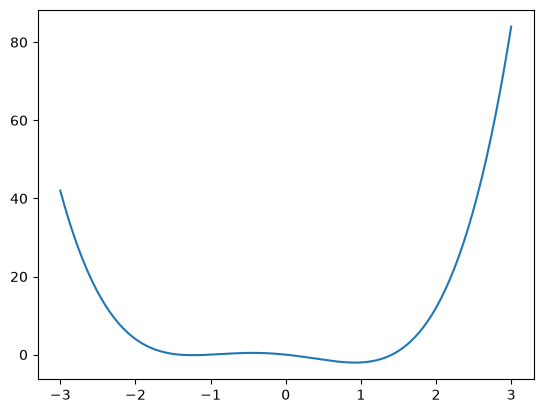

In [2]:
#### punto 2 ########################

x = np.linspace(-3, 3, 200)
y = f(x)

# Visualizzo
plt.plot(x, y)
plt.show()

-2.0377480413610463


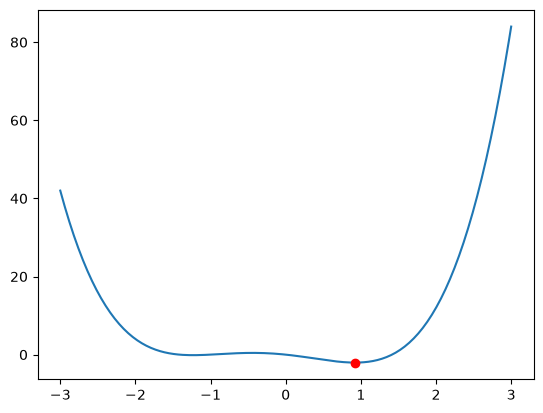

In [3]:
#### punto 3 ########################

x_star = 0.92222
y_star = f(x_star)
print(y_star)
#grad_star = grad_f(x_star)
#print(grad_star)

# Visualizzo
plt.plot(x, y)
plt.plot(x_star, y_star, 'o', color="red")
#plt.ylim( (-2.5, 2.5) )
plt.show()

#print(f"x=1 y={f(1)}")
#print(f"x=0.9 y={f(0.9)}")

In [4]:
#### punto 4 ########################

def discesa_gradiente(
    f,              # funzione obiettivo
    grad_f,         # gradiente della funzione obiettivo
    x0,             # punto iniziale 
    alpha=1.0,      # lunghezza del passo, alpha>0
    tol_grad=1e-6,  # tolleranza sulla norma del gradiente
    maxit=1000      # massimo numero di iterazioni
):
    """
    Discesa del gradiente con passo fisso.
    """

    # Inizializzazioni
    x = np.asarray(x0, dtype=float).copy()

    k = 0
    fx = f(x)
    grad = grad_f(x)
    grad_norm = np.linalg.norm(grad)

    history = {
        "x": [x.copy()],
        "f": [fx],
        "grad_norm": [grad_norm]
    }

    # Ciclo iterativo di risoluzione
    while grad_norm > tol_grad and k < maxit:

        # Direzione di discesa
        p = -grad

        # Aggiornamento dell'iterata
        x = x + alpha * p
        k += 1

        # Aggiornamento delle quantità
        fx = f(x)
        grad = grad_f(x)
        grad_norm = np.linalg.norm(grad)

        # Salvataggio della storia
        history["x"].append(x.copy())
        history["f"].append(fx)
        history["grad_norm"].append(grad_norm)

    if grad_norm <= tol_grad:  # x è punto stazionario
        print(f"Convergenza numerica raggiunta in {k} iterazioni.")
    else:
        print("Raggiunto il numero massimo di iterazioni.")

    return x, history


def discesa_gradiente_bt(
    f,              # funzione obiettivo
    grad_f,         # gradiente della funzione obiettivo
    x0,             # punto iniziale 
    alpha0=1.0,     # lunghezza del passo iniziale, 0<alpha
    rho=0.5,        # fattore di riduzione del passo, 0<rho<1
    c1=1e-4,        # parametro della condizione di Armijo, 0<c1<1
    tau=1e-12,      # lunghezza del minimo passo ammesso, 0<rho<alpha
    tol_grad=1e-6,  # tolleranza sulla norma del gradiente
    maxit=1000      # massimo numero di iterazioni
):
    """
    Discesa del gradiente con backtracking di Armijo.
    """

    # Controlli sugli imput
    if not 0 < rho < 1:
        raise ValueError("rho deve appartenere a (0, 1).")

    if not 0 < c1 < 1:
        raise ValueError("c1 deve appartenere a (0, 1).")

    if not 0 < tau <= alpha0:
        raise ValueError("tau deve essere positivo e non superiore ad alpha0.")

    # Inizializzazioni
    x = np.asarray(x0, dtype=float).copy()

    k = 0
    fx = f(x)
    grad = grad_f(x)
    grad_norm = np.linalg.norm(grad)

    history = {
        "x": [x.copy()],
        "f": [fx],
        "grad_norm": [grad_norm],
        "alpha": []
    }

    # Ciclo iterativo di risoluzione
    while grad_norm > tol_grad and k < maxit:

        # Direzione di discesa
        p = -grad

        # Scelta del passo di discesa
        alpha = alpha0

        while f(x + alpha * p) > fx + c1 * alpha * np.dot(grad, p): # Backtracking di Armijo

            if alpha <= tau:
                print("Passo minimo raggiunto senza soddisfare Armijo.")
                return x, history

            alpha = max(rho * alpha, tau)

        # Aggiornamento dell'iterata
        x = x + alpha * p
        k += 1

        # Aggiornamento delle quantità
        fx = f(x)
        grad = grad_f(x)
        grad_norm = np.linalg.norm(grad)

        # Salvataggio della storia
        history["x"].append(x.copy())
        history["f"].append(fx)
        history["grad_norm"].append(grad_norm)
        history["alpha"].append(alpha)

    if grad_norm <= tol_grad:  # x è punto stazionario
        print(f"Convergenza numerica raggiunta in {k} iterazioni.")
    else:
        print("Raggiunto il numero massimo di iterazioni.")

    return x, history




Raggiunto il numero massimo di iterazioni.
0.9221880518912546
Convergenza numerica raggiunta in 20 iterazioni.
0.9222247468578356
Errore della soluzione: 3.1948108745405435e-05
Errore della soluzione con bt: 4.746857835580265e-06


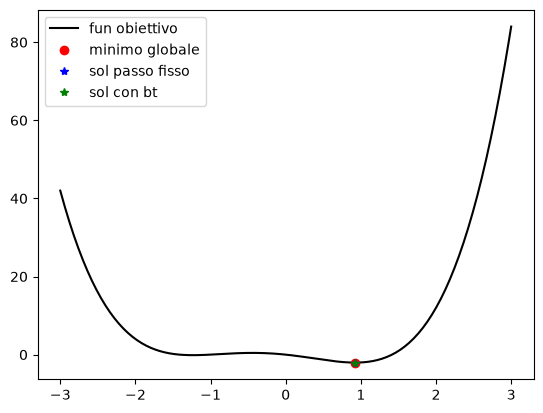

In [24]:
x_start = 0
maxiter = 100

passo = 0.01
x_sol, hist = discesa_gradiente(f, grad_f, x0=x_start, maxit=maxiter, alpha=passo)
print(x_sol)

alpha_start = 1
x_sol_bt, hist_bt = discesa_gradiente_bt(f, grad_f, x0=x_start, maxit=maxiter, alpha0=alpha_start)
print(x_sol_bt)

errore = np.fabs(x_star-x_sol)
print(f"Errore della soluzione: {errore}")
errore_bt = np.fabs(x_star-x_sol_bt)
print(f"Errore della soluzione con bt: {errore_bt}")

# Visualizzo
plt.plot(x, y, color="black")
plt.plot(x_star,    y_star,         'o', color="red")
plt.plot(x_sol,     f(x_sol),       '*', color="blue")
plt.plot(x_sol_bt,  f(x_sol_bt),    '*', color="green")
plt.legend( ["fun obiettivo", "minimo globale", "sol passo fisso", "sol con bt"] )
# plt.xlim( (0.7, 1.2) )
# plt.ylim( (-2.5, 2.5) )
plt.show()

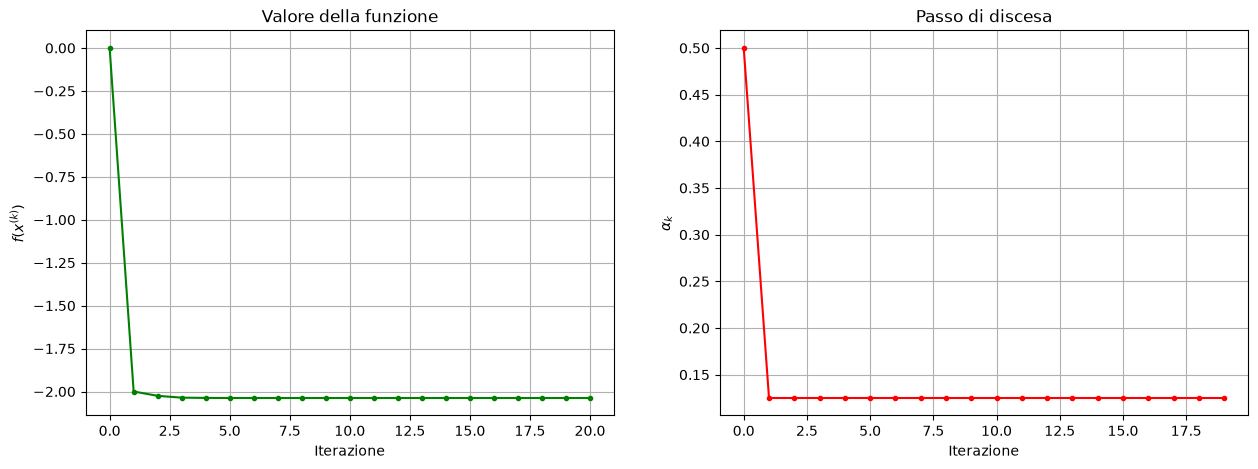

In [25]:
f_values = np.array(hist_bt["f"])
alpha_values = np.array(hist_bt["alpha"])

plt.figure(figsize=(15, 5))

# Primo grafico: valori della funzione
plt.subplot(1, 2, 1)
plt.plot(f_values, ".-", color = 'green')
plt.xlabel("Iterazione")
plt.ylabel(r"$f(x^{(k)})$")
plt.title("Valore della funzione")
plt.grid(True)

# Secondo grafico: norma del gradiente
plt.subplot(1, 2, 2)
# plt.semilogy(alpha_values, ".-", color = "red")
plt.plot(alpha_values, ".-", color = "red")
plt.xlabel("Iterazione")
plt.ylabel(r"$\alpha_k$")
# plt.ylim([0, 10])
plt.title("Passo di discesa")
plt.grid(True)

plt.show()

Raggiunto il numero massimo di iterazioni.
inf
Convergenza numerica raggiunta in 19 iterazioni.
0.9222247468578356
Errore della soluzione: inf
Errore della soluzione con bt: 4.746857835580265e-06


C:\Users\elena\AppData\Local\Temp\ipykernel_53320\2841095579.py:7: RuntimeWarning: overflow encountered in scalar power
  y = x**4 +x**3 -2*x**2 -2*x
C:\Users\elena\AppData\Local\Temp\ipykernel_53320\2841095579.py:7: RuntimeWarning: invalid value encountered in scalar add
  y = x**4 +x**3 -2*x**2 -2*x
C:\Users\elena\AppData\Local\Temp\ipykernel_53320\2841095579.py:11: RuntimeWarning: overflow encountered in scalar power
  y = 4*x**3 + 3*x**2 -4*x -2
C:\Users\elena\AppData\Local\Temp\ipykernel_53320\2841095579.py:7: RuntimeWarning: invalid value encountered in scalar subtract
  y = x**4 +x**3 -2*x**2 -2*x
C:\Users\elena\AppData\Local\Temp\ipykernel_53320\2841095579.py:11: RuntimeWarning: invalid value encountered in scalar subtract
  y = 4*x**3 + 3*x**2 -4*x -2


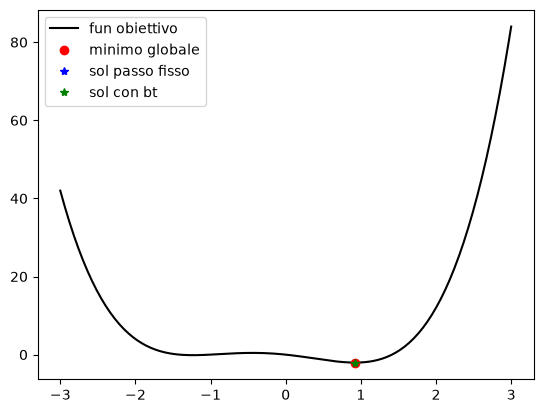

In [21]:
#### punto 5 ########################

x_start = 1

passo = 1
x_sol, hist = discesa_gradiente(f, grad_f, x0=x_start, maxit=maxiter, alpha=passo)
print(x_sol)

alpha_start = 1
x_sol_bt, hist_bt = discesa_gradiente_bt(f, grad_f, x0=x_start, maxit=maxiter, alpha0=alpha_start)
print(x_sol_bt)

errore = np.fabs(x_star-x_sol)
print(f"Errore della soluzione: {errore}")
errore_bt = np.fabs(x_star-x_sol_bt)
print(f"Errore della soluzione con bt: {errore_bt}")

# Visualizzo
plt.plot(x, y, color="black")
plt.plot(x_star,    y_star,         'o', color="red")
plt.plot(x_sol,     f(x_sol),       '*', color="blue")
plt.plot(x_sol_bt,  f(x_sol_bt),    '*', color="green")
plt.legend( ["fun obiettivo", "minimo globale", "sol passo fisso", "sol con bt"] )
# plt.xlim( (0.7, 1.2) )
# plt.ylim( (-2.5, 2.5) )
plt.show()

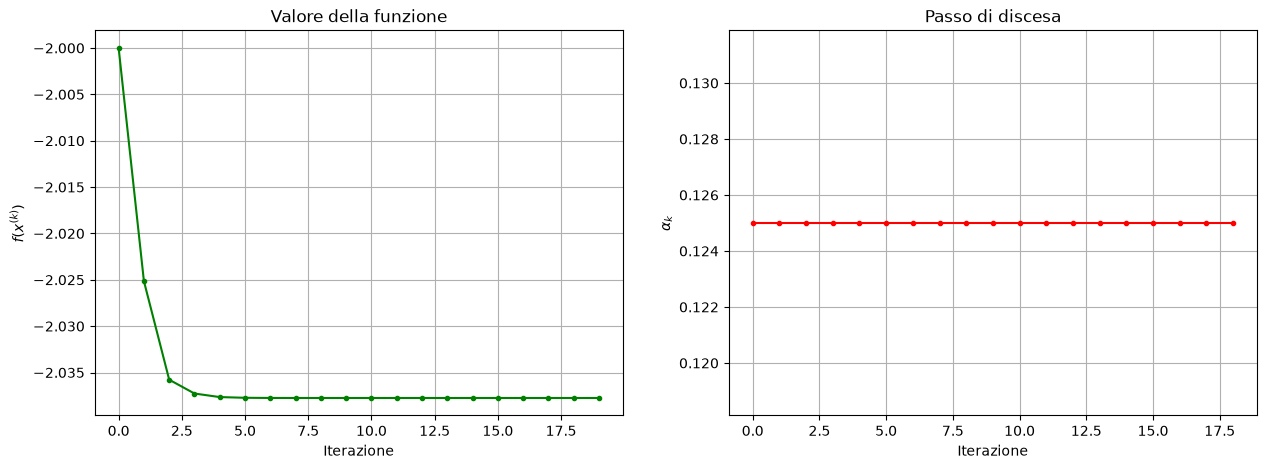

In [ ]:
f_values = np.array(hist_bt["f"])
alpha_values = np.array(hist_bt["alpha"])

plt.figure(figsize=(15, 5))

# Primo grafico: valori della funzione
plt.subplot(1, 2, 1)
plt.plot(f_values, ".-", color = 'green')
plt.xlabel("Iterazione")
plt.ylabel(r"$f(x^{(k)})$")
plt.title("Valore della funzione")
plt.grid(True)

# Secondo grafico: norma del gradiente
plt.subplot(1, 2, 2)
# plt.semilogy(alpha_values, ".-", color = "red")
plt.plot(alpha_values, ".-", color = "red")
plt.xlabel("Iterazione")
plt.ylabel(r"$\alpha_k$")
# plt.ylim([0, 10])
plt.title("Passo di discesa")
plt.grid(True)

plt.show()

In [ ]:
#### punto 6 ########################

# TO DO